# Módulo 12 · Invirtiendo la diferenciación

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/05-invirtiendo-la-diferenciacion`.

Diferenciar una serie (restar cada valor del anterior) es el truco estándar para conseguir estacionariedad antes de ajustar un AR/MA/ARMA — o se hace a mano, o lo hace `ARIMA` internamente con el parámetro `d`. Pero una predicción hecha sobre la serie diferenciada está en la **escala equivocada**: predice variaciones, no precios. Este notebook muestra cómo volver de esa escala a la original, paso a paso, con el precio del oro.

## El dataset: oro (futuros, `GC=F`)

En vez de depender de un CSV local con ruta absoluta al disco de quien lo generó —un problema clásico de portabilidad—, aquí se usa una descarga real y propia vía `yfinance` — mismo mecanismo verificado en el resto del módulo.

In [1]:
import yfinance as yf

gold = yf.download("GC=F", start="2015-01-01", end="2026-09-16", interval="1d", threads=False)["Close"]
gold = gold.squeeze()
gold.name = "gold_usd"
gold = gold.dropna()
print(gold.shape)
gold.tail()

[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

(2942,)


Date
2026-09-09    4460.700195
2026-09-10    4407.299805
2026-09-11    4408.899902
2026-09-14    4351.899902
2026-09-15    4332.799805
Name: gold_usd, dtype: float64

## Diferenciar a mano

`d1 = precio.diff()` es exactamente la transformación que `ARIMA(p, 1, q)` hace por dentro cuando se le pasa `d=1`. Aquí se hace explícita para poder invertirla explícitamente después.

In [2]:
d1 = gold.diff().dropna()
print("precio original — media:", round(gold.mean(), 2), "  desv. típica:", round(gold.std(), 2))
print("serie diferenciada — media:", round(d1.mean(), 4), "  desv. típica:", round(d1.std(), 2))

precio original — media: 1944.36   desv. típica: 934.97
serie diferenciada — media: 1.07   desv. típica: 30.35


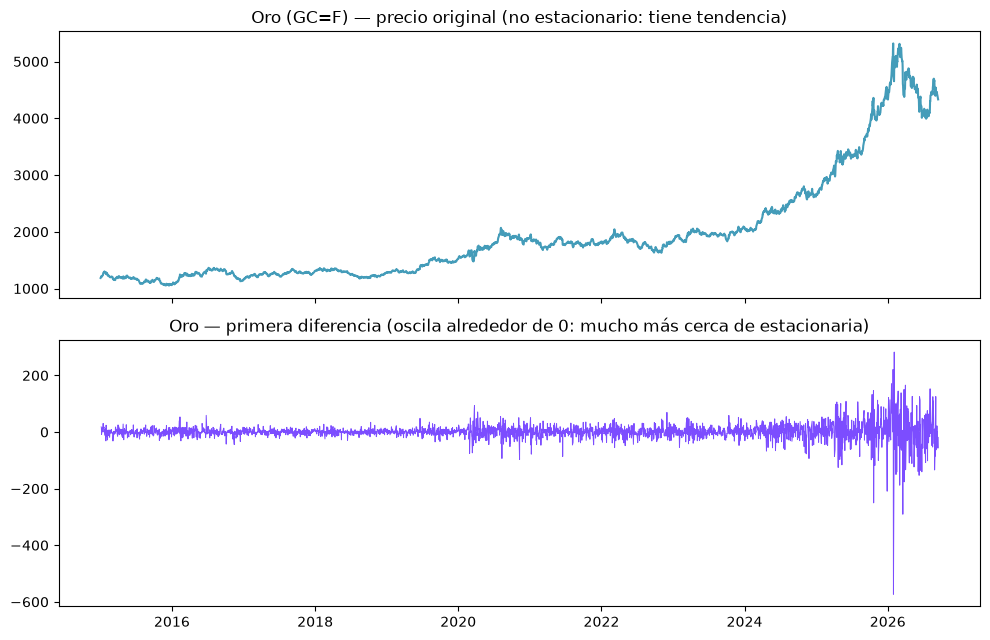

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
axes[0].plot(gold.index, gold.values, color="#449cb9")
axes[0].set_title("Oro (GC=F) — precio original (no estacionario: tiene tendencia)")
axes[1].plot(d1.index, d1.values, color="#7c4dff", linewidth=0.7)
axes[1].set_title("Oro — primera diferencia (oscila alrededor de 0: mucho más cerca de estacionaria)")
plt.tight_layout()
plt.savefig("gold_diferenciacion.png", dpi=110, bbox_inches="tight")
plt.show()

## Ajustar un modelo sobre la serie diferenciada

Se separan los últimos 20 días como test, se ajusta un modelo simple ARMA(2,2) sobre las diferencias de entrenamiento, y se predicen 20 pasos — en la escala de **diferencias**, todavía no en dólares.

In [4]:
from statsmodels.tsa.arima.model import ARIMA

train_d1, test_d1 = d1.iloc[:-20], d1.iloc[-20:]
# .reset_index(drop=True): el índice de fechas del oro no tiene una frecuencia fija (festivos,
# fines de semana con calendario irregular por mercado) y ARIMA exige una para poder extrapolar
# — se modela sobre un índice entero simple y se reasignan las fechas reales al reconstruir.
modelo = ARIMA(train_d1.reset_index(drop=True), order=(2, 0, 2)).fit()
pred_d1 = modelo.forecast(steps=20)
print(pred_d1.head())

2921   -2.392506
2922    0.291693
2923    1.773836
2924    0.771883
2925    1.305703
Name: predicted_mean, dtype: float64


## Invertir la diferenciación: de vuelta a dólares

Una diferencia predicha no dice nada por sí sola ("+1,3" no es un precio). Para volver a la escala original hay que **acumular** las diferencias predichas (`cumsum`) y sumarlas al **último precio real conocido** antes del tramo de test — exactamente la operación inversa de `.diff()`.

In [5]:
import pandas as pd

ultimo_precio_conocido = gold.loc[:train_d1.index[-1]].iloc[-1]
pred_precio_valores = ultimo_precio_conocido + pred_d1.cumsum().values

real_precio = gold.iloc[-20:]

comparacion = pd.DataFrame({"real": real_precio.values, "predicho": pred_precio_valores}, index=real_precio.index)
comparacion.head()

,real,predicho
Date,,
2026-08-18,4420.600098,4471.307689
2026-08-19,4545.299805,4471.599382
2026-08-20,4571.399902,4473.373218
2026-08-21,4680.600098,4474.145101
2026-08-24,4697.799805,4475.450803


In [6]:
rmse_precio = ((comparacion["real"] - comparacion["predicho"]) ** 2).mean() ** 0.5
print("RMSE en la escala de precio (dólares):", round(rmse_precio, 2))
print("precio medio del tramo test:", round(comparacion["real"].mean(), 2))

RMSE en la escala de precio (dólares): 122.71
precio medio del tramo test: 4508.35


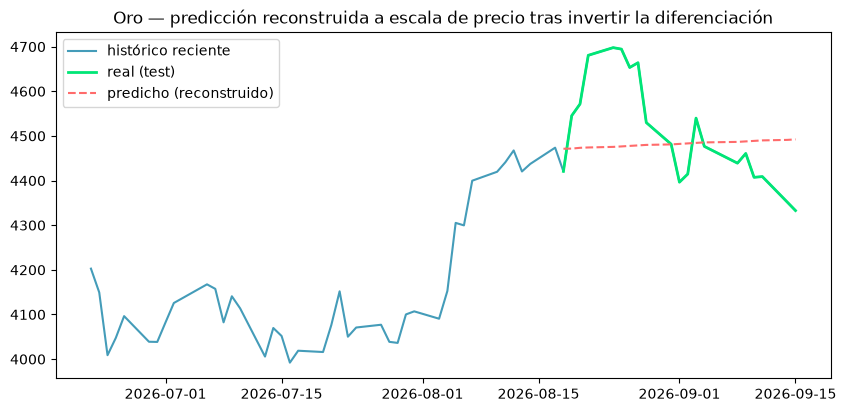

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(gold.index[-60:], gold.values[-60:], color="#449cb9", label="histórico reciente")
ax.plot(comparacion.index, comparacion["real"].values, color="#00e676", label="real (test)", linewidth=2)
ax.plot(comparacion.index, comparacion["predicho"].values, color="#ff6b6b", linestyle="--", label="predicho (reconstruido)")
ax.legend()
ax.set_title("Oro — predicción reconstruida a escala de precio tras invertir la diferenciación")
plt.savefig("gold_forecast_reconstruido.png", dpi=110, bbox_inches="tight")
plt.show()

## Por qué este paso se olvida tan a menudo

Si `ARIMA(p, 1, q)` se ajusta directamente sobre el precio (pasando `d=1`), `statsmodels` invierte la diferenciación automáticamente al llamar a `.forecast()` — el resultado ya viene en dólares. El riesgo real aparece cuando alguien diferencia **a mano** para "ayudar" al modelo con la estacionariedad (una práctica común, sobre todo fuera de la familia ARIMA — redes neuronales, gradient boosting sobre series, etc.) y se olvida de deshacer la transformación antes de evaluar o reportar el resultado: un RMSE calculado sobre diferencias no es comparable a un RMSE calculado sobre precios, y un error así pasa desapercibido porque el código "funciona" sin lanzar ningún error — solo da un número sin sentido.

**Conclusión**: diferenciar y volver a integrar (acumular) es una pareja de operaciones inversas, igual que "restar" y "sumar". El paso que hay que verificar siempre, con un ejemplo como este, es cuál es el último valor real que ancla la reconstrucción.